(a) Load the dataset into a Pandas DataFrame and display the first few rows to understand the structure of the dataset.

In [1]:
import pandas as pd

# Load the dataset
path = r"C:\Users\MEridu\OneDrive - Plan International\Desktop\UCU\Codiing UCU\env\visualization\exams\medical_insurance_dataset.csv"

df = pd.read_csv(path)

# Display shape and first few rows
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (2772, 7)

First 5 rows:


,age,gender,bmi,no_of_children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520


From the above, this shows that we have 7 colunmns rangin from age to charges with 2,772 entries 

Understanding the dataset after loading

In [2]:
df.dtypes

age                object
gender              int64
bmi               float64
no_of_children      int64
smoker             object
region              int64
charges           float64
dtype: object

This is to understand the dataset and from the output it shows that there is variation in the data type as compared to what is the dataset decription and this will need to be fixed 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2772 non-null   object 
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2772 non-null   object 
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 151.7+ KB


From the above is shows that there are some inconsistency in the dataset, Age is shwoing object yet its integer  and somker as compared to the actual dataset. Thus we need to conver this to variables.

This means that age and smoker are  stored as text instead of numeric 

(b) Examine the dataset to determine whether there are any missing or null values in the columns.
Identify the columns affected and apply appropriate strategies to handle the missing data
depending on the datatype of the attribute. Verify the changes using df.info().

In [5]:
# Check standard nulls
print("=== Missing Values ===")
print(df.isnull().sum())

# Also check for '?' which act as hidden missing values
print("\n=== '?' counts per column ===")
for col in df.columns:
    count = (df[col].astype(str) == '?').sum()
    if count > 0:
        print(f"{col}: {count} '?' found")

=== Missing Values ===
age               0
gender            0
bmi               0
no_of_children    0
smoker            0
region            0
charges           0
dtype: int64

=== '?' counts per column ===
age: 4 '?' found
smoker: 7 '?' found


Although no standard null values (NaN) were detected in the dataset, further inspection revealed the presence of non‑standard missing value indicators represented by the character ‘?’. Specifically, the age column contained four (4) such values, while the smoker column contained seven (7). The values are not correct and now we need to fix them for us to do proper and better analysis.

# Handling the missing values and fixing it

In [6]:
# Step 1: Replace '?' with NaN
df.replace('?', pd.NA, inplace=True)

# Step 2: Fix 'age' — fill missing with median, cast to int
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['age'] = df['age'].fillna(df['age'].median()).astype(int)

# Step 3: Fix 'smoker' — fill missing with mode, cast to int
df['smoker'] = pd.to_numeric(df['smoker'], errors='coerce')
df['smoker'] = df['smoker'].fillna(df['smoker'].mode()[0]).astype(int)

print("Done! Missing values handled.")
print("\n=== Confirm Zero Nulls ===")
print(df.isnull().sum())

Done! Missing values handled.

=== Confirm Zero Nulls ===
age               0
gender            0
bmi               0
no_of_children    0
smoker            0
region            0
charges           0
dtype: int64


From the output above it shows that the missing values have been handled also age was changed to integer and smoker 

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2772 non-null   int64  
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2772 non-null   int64  
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 151.7 KB


(c) The charges column contains values with more than two decimal places. Transform the column
so that all values are rounded to two decimal places. Display the first five rows to confirm that
the update has been applied correctly.

# checking for columns with more 2 decimanls 

In [8]:
# Check decimal places for all numeric columns
print("=== Columns with more than 2 decimal places ===")
for col in df.select_dtypes(include=['float64']).columns:
    # Check if any value has more than 2 decimal places
    has_more = df[col].apply(lambda x: len(str(x).split('.')[-1]) > 2).any()
    if has_more:
        print(f"\n{col}: has values with more than 2 decimal places")
        print("Sample values:", df[col].head().tolist())
    else:
        print(f"\n{col}: OK (2 or fewer decimal places)")

=== Columns with more than 2 decimal places ===

bmi: has values with more than 2 decimal places
Sample values: [27.9, 33.77, 33.0, 22.705, 28.88]

charges: has values with more than 2 decimal places
Sample values: [16884.924, 1725.5523, 4449.462, 21984.47061, 3866.8552]


Before we round off, I did a check on which columns have figures with more than 2 decimal points it shows that we have two colunmns with more 2 decimal points and that is bmi and Charges 
so now we need to fix those two colunmns 

In [9]:
# Round both bmi and charges to 2 decimal places
df['bmi'] = df['bmi'].round(2)
df['charges'] = df['charges'].round(2)

print("=== First 5 rows after rounding ===")
df.head()

=== First 5 rows after rounding ===


,age,gender,bmi,no_of_children,smoker,region,charges
0,19,1,27.90,0,1,3,16884.92
1,18,2,33.77,1,0,4,1725.55
2,28,2,33.00,3,0,4,4449.46
3,33,2,22.70,0,0,1,21984.47
4,32,2,28.88,0,0,1,3866.86


The above output confirms that the rounding off was done successfully

In [10]:
# Verify both columns are now 2 decimal places
print("=== Confirming fix ===")
for col in df.select_dtypes(include=['float64']).columns:
    has_more = df[col].apply(lambda x: len(str(x).split('.')[-1]) > 2).any()
    if has_more:
        print(f"{col}: ❌ Still has more than 2 decimal places")
    else:
        print(f"{col}: ✅ OK - 2 or fewer decimal places")

=== Confirming fix ===
bmi: ✅ OK - 2 or fewer decimal places
charges: ✅ OK - 2 or fewer decimal places


From the output above it confirms the rounding of to 2 decimanl point was sucessful

(d) Save the cleaned and transformed dataset using your last name as the filename in CSV format.
Example: YourLastName.csv (e.g., Nuwe.csv).

In [12]:

# Save the cleaned and transformed dataset to CSV
df.to_csv("Eridu.csv", index=False)

print("Cleaned dataset saved successfully as Eridu.csv")

print("Shape:", df.shape)


Cleaned dataset saved successfully as Eridu.csv
Shape: (2772, 7)


From the above output it clearly show that the dataset has been saved successfully using my last name Eridu

Saving it in my working folder as well for reference 

In [13]:

df.to_csv(
    r"C:\Users\MEridu\OneDrive - Plan International\Desktop\UCU\Codiing UCU\env\visualization\exams\Eridu.csv",
    index=False
)


(e) Using the cleaned dataset, generate appropriate visualizations to explore how different attributes
may influence the insurance charges.

# (i) Show the relationship between bmi and charges.

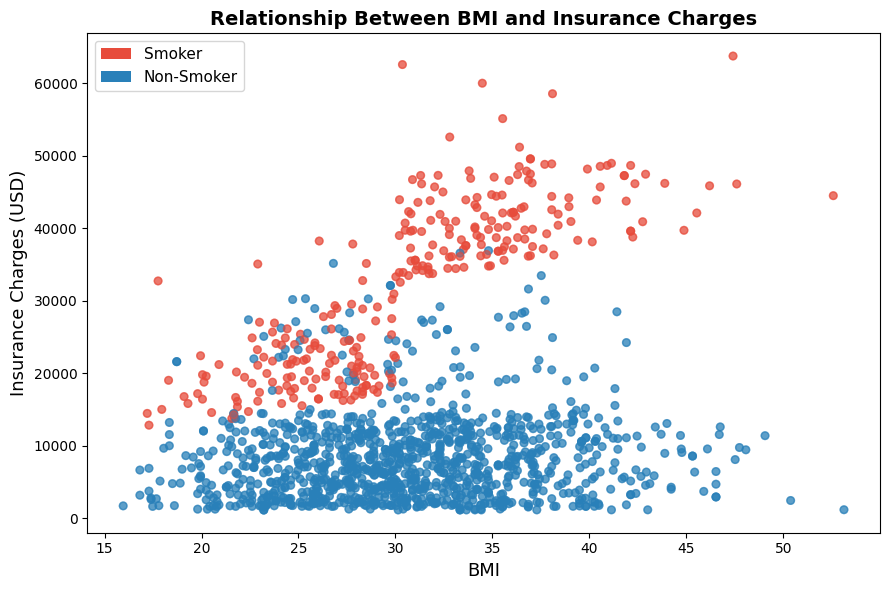

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(9, 6))

# Color points by smoker status
colors = df['smoker'].map({1: '#E74C3C', 0: '#2980B9'})

ax.scatter(df['bmi'], df['charges'], c=colors, alpha=0.5, s=30)

# Labels and title
ax.set_xlabel('BMI', fontsize=13)
ax.set_ylabel('Insurance Charges (USD)', fontsize=13)
ax.set_title('Relationship Between BMI and Insurance Charges', fontsize=14, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E74C3C', label='Smoker'),
    Patch(facecolor='#2980B9', label='Non-Smoker')
]
ax.legend(handles=legend_elements, fontsize=11)

plt.tight_layout()
plt.show()

The chart above shows a clear positive relationship between BMI and insurance charges. Charges increase as BMI rises, but smokers consistently incur much higher costs than non-smokers at the same BMI levels. Non-smokers mostly cluster at lower charges across all BMI values, while smokers show a wide spread with very high charges, especially at moderate to high BMI. Overall, smoking status has a much stronger impact on insurance charges than BMI alone.

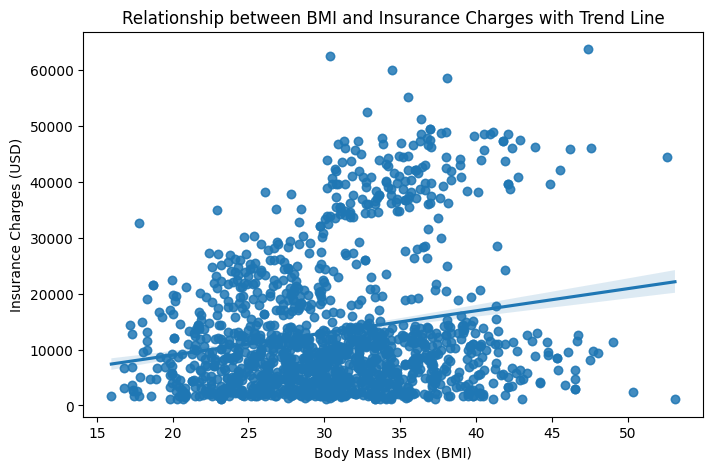

In [16]:

plt.figure(figsize=(8, 5))
sns.regplot(x='bmi', y='charges', data=df, scatter_kws={'alpha':0.6})

plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Insurance Charges (USD)')
plt.title('Relationship between BMI and Insurance Charges with Trend Line')

plt.show()


In [17]:

correlation = df['bmi'].corr(df['charges'])
print("Correlation between BMI and charges:", correlation)


Correlation between BMI and charges: 0.19983889451681064


The correlation between BMI and insurance charges is approximately 0.20, indicating a weak to moderate positive relationship. This suggests that as BMI increases, insurance charges tend to increase slightly; however, BMI alone explains only a small portion of the variation in insurance costs. Compared to other factors such as smoking status, BMI is a less influential predictor of insurance charges.

# (ii) Compare charges for smokers and non-smokers.

### Note: 
# 0  represnts non somkers 
# 1 represnts smokers 

C:\Users\MEridu\AppData\Local\Temp\ipykernel_32368\3014086688.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


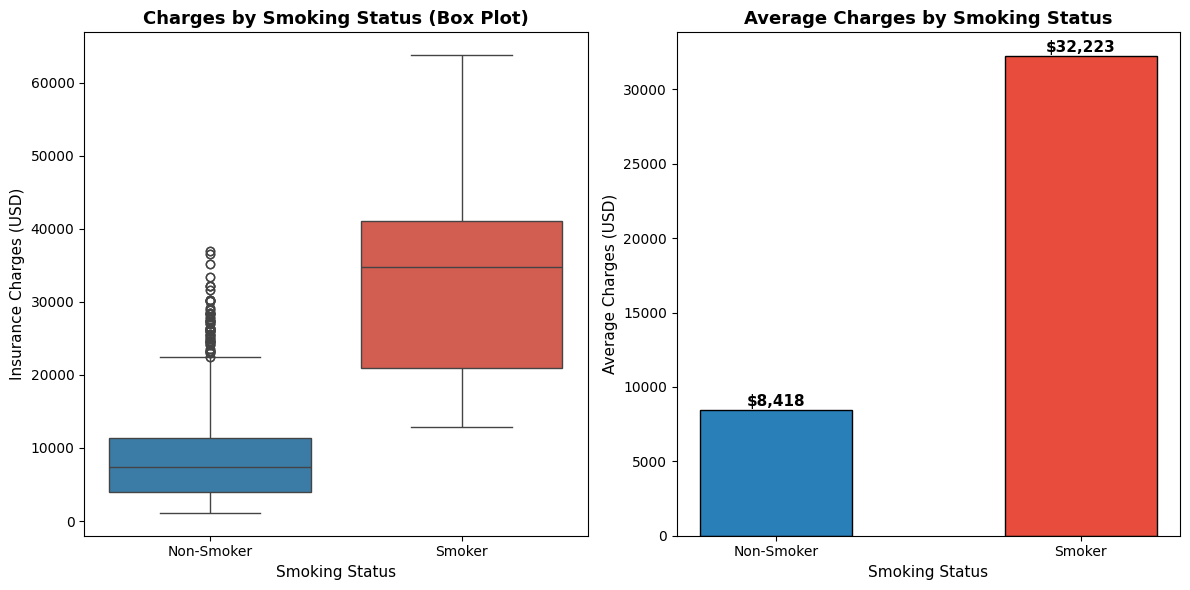

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# ── Plot 1: Box Plot 
sns.boxplot(
    x='smoker', y='charges', data=df,
    palette=['#2980B9', '#E74C3C'],  # list instead of dictionary
    ax=axes[0]
)
axes[0].set_title('Charges by Smoking Status (Box Plot)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Smoking Status', fontsize=11)
axes[0].set_ylabel('Insurance Charges (USD)', fontsize=11)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Non-Smoker', 'Smoker'])

# ── Plot 2: Bar Chart of Average Charges 
avg_charges = df.groupby('smoker')['charges'].mean()
bars = axes[1].bar(
    ['Non-Smoker', 'Smoker'],
    avg_charges.values,
    color=['#2980B9', '#E74C3C'],
    width=0.5, edgecolor='black'
)
axes[1].set_title('Average Charges by Smoking Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Smoking Status', fontsize=11)
axes[1].set_ylabel('Average Charges (USD)', fontsize=11)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        height + 300,
        f'${height:,.0f}',
        ha='center', fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.show()

The visualizations clearly show a substantial difference in insurance charges between smokers and non‑smokers. The box plot indicates that smokers consistently incur much higher charges, with a higher median and a wider spread, reflecting greater variability and more extreme costs. The bar chart reinforces this finding by showing that the average insurance charge for smokers (about $32,223) is nearly four times higher than that of non‑smokers (about $8,418). Overall, the results confirm that smoking status is a major driver of medical insurance costs, both in terms of typical expenses and financial risk.

(f) Conduct the correlation analysis for the dataset (statistically and visually). Based on the correlation
results, discuss which variables appear to have stronger relationships with the insurance
charges.

# Statistical Correlation

In [20]:
import pandas as pd

# Compute full correlation matrix
corr_matrix = df.corr(numeric_only=True)

print("=== Full Correlation Matrix ===")
print(corr_matrix.round(2))

print("\n=== Correlation with Charges (Sorted) ===")
print(corr_matrix['charges'].sort_values(ascending=False).round(3))

=== Full Correlation Matrix ===
                 age  gender   bmi  no_of_children  smoker  region  charges
age             1.00   -0.03  0.11            0.04   -0.02   -0.01     0.30
gender         -0.03    1.00  0.04            0.02    0.08    0.02     0.06
bmi             0.11    0.04  1.00           -0.00    0.01    0.27     0.20
no_of_children  0.04    0.02 -0.00            1.00    0.01   -0.03     0.07
smoker         -0.02    0.08  0.01            0.01    1.00    0.05     0.79
region         -0.01    0.02  0.27           -0.03    0.05    1.00     0.05
charges         0.30    0.06  0.20            0.07    0.79    0.05     1.00

=== Correlation with Charges (Sorted) ===
charges           1.000
smoker            0.789
age               0.299
bmi               0.200
no_of_children    0.066
gender            0.063
region            0.054
Name: charges, dtype: float64


The correlation analysis shows that smoking status has the strongest positive relationship with insurance charges (correlation ≈ 0.79), confirming it as the most influential predictor. Age (≈ 0.30) and BMI (≈ 0.20) also exhibit moderate positive correlations with charges, indicating that insurance costs generally increase with age and higher body mass index. In contrast, number of children, gender, and region have weak correlations with charges, suggesting they contribute relatively little on their own. Overall, the results highlight that lifestyle and health factors especially smoking drive insurance costs more strongly than demographic variables.

# Visual Correlation (Heatmap)

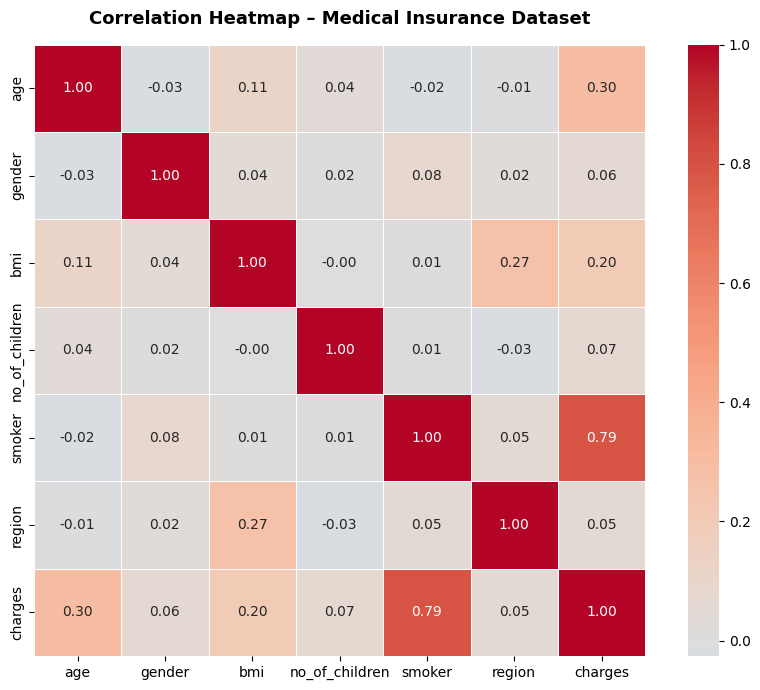

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, ax = plt.subplots(figsize=(9, 7))

# Generate heatmap
sns.heatmap(
    corr_matrix,
    annot=True,          # show values
    fmt='.2f',           # 2 decimal places
    cmap='coolwarm',     # red=positive, blue=negative
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Correlation Heatmap – Medical Insurance Dataset',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

The correlation heatmap shows that smoking status has the strongest positive relationship with insurance charges (correlation ≈ 0.79), indicating it is the most influential factor. Age (≈ 0.30) and BMI (≈ 0.20) also show moderate positive correlations with charges, suggesting that insurance costs tend to increase with higher age and body mass index. Other variables such as number of children, gender, and region exhibit weak correlations with charges, implying a relatively minor influence. Overall, the heatmap confirms that lifestyle and health factors especially smoking play a much more significant role in determining medical insurance charges than demographic characteristics.

# Bar chart of correlations with charges

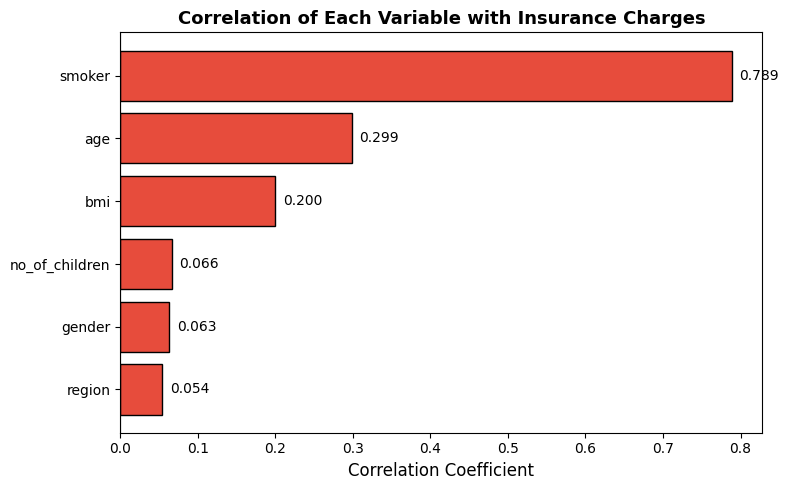

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))

# Get correlations with charges excluding charges itself
corr_charges = corr_matrix['charges'].drop('charges').sort_values()

colors = ['#E74C3C' if v > 0 else '#2980B9' for v in corr_charges.values]

bars = ax.barh(corr_charges.index, corr_charges.values, color=colors, edgecolor='black')

ax.set_xlabel('Correlation Coefficient', fontsize=12)
ax.set_title('Correlation of Each Variable with Insurance Charges',
             fontsize=13, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)

# Add value labels
for bar, val in zip(bars, corr_charges.values):
    ax.text(
        val + 0.01 if val >= 0 else val - 0.01,
        bar.get_y() + bar.get_height()/2,
        f'{val:.3f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=10
    )

plt.tight_layout()
plt.show()

Key Discussion Points:

Smoker has the strongest relationship with charges (r ≈ 0.789)  smokers pay far more

Age shows a moderate positive correlation (r ≈ 0.299) older people pay more

BMI has a moderate positive correlation (r ≈ 0.200)  higher BMI increases costs

Children, gender and region have very weak correlations  minimal influence on charge

## Part C: Predictive Modeling and Analytical Insights ##

(a) Develop a simple linear regression model that predicts charges using only the smoker attribute.
Compute and report the R2 score of the model. Briefly comment on what this result suggests
about the importance of smoking status.

preparing  data for a linear regression model and spliting  it into training and testing sets

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np

# ── Prepare data 
X = df[['smoker']]   # single feature
y = df['charges']    # target

# ── Split into train and test sets (80/20) 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape[0])
print("Testing set size: ", X_test.shape[0])

Training set size: 2217
Testing set size:  555


from the above output The code selected  smoking status as the predictor variable and insurance charges as the response variable, then splits the dataset into a training set of 2,217 observations and a testing set of 555 observations to enable reliable training and evaluation of a linear regression model.”

Train and Evaluate the Mode

In [ ]:
#Train the model 
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set 
y_pred = model.predict(X_test)

# ── Compute R² score
r2 = r2_score(y_test, y_pred)

print("=== Simple Linear Regression Results ===")
print(f"Intercept        : ${model.intercept_:,.2f}")
print(f"Coefficient      : ${model.coef_[0]:,.2f}")
print(f"R² Score         : {r2:.4f}")

=== Simple Linear Regression Results ===
Intercept        : $8,443.40
Coefficient      : $23,544.51
R² Score         : 0.5991


The simple linear regression model was fitted to examine the relationship between smoking status and medical insurance charges, and the results are summarized as follows

Intercept = $8,443.40
The intercept represents the expected insurance charges when the smoker variable is equal to 0.
In practical terms, this means that individuals in the reference group (non‑smokers) are estimated to incur average annual insurance charges of approximately $8,443.40.

Coefficient = $23,544.51
The regression coefficient indicates the change in insurance charges associated with smoking status.
Specifically, being a smoker is associated with an increase of approximately $23,544.51 in annual insurance charges compared to a non‑smoker

# This shows that smoking has a strong and substantial financial impact on medical insurance costs.


 R² Score = 0.5991
The R² (coefficient of determination) measures how much of the variability in insurance charges is explained by the model.

An R² value of 0.5991 means that about 59.91% of the variation in insurance charges is explained solely by smoking status.
This indicates a moderately strong explanatory power for a simple linear regression with only one predictor.

## The regression results indicate that non‑smokers have baseline insurance charges of approximately $8,443, while smokers incur an additional $23,545 on average, with smoking status alone explaining about 59.9% of the variability in insurance charges.”

Visualise the Regression

c:\Users\MEridu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


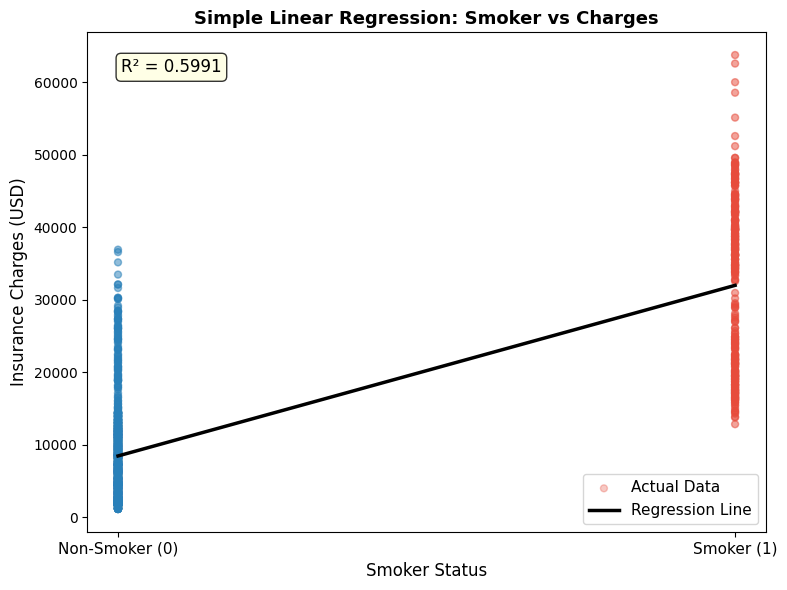

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter actual data
colors = df['smoker'].map({1: '#E74C3C', 0: '#2980B9'})
ax.scatter(df['smoker'], df['charges'],
           c=colors, alpha=0.3, s=25, label='Actual Data')

# Regression line
x_line = np.array([[0], [1]])
y_line = model.predict(x_line)
ax.plot(x_line, y_line, color='black',
        linewidth=2.5, label='Regression Line')

# Labels
ax.set_xticks([0, 1])
ax.set_xticklabels(['Non-Smoker (0)', 'Smoker (1)'], fontsize=11)
ax.set_xlabel('Smoker Status', fontsize=12)
ax.set_ylabel('Insurance Charges (USD)', fontsize=12)
ax.set_title('Simple Linear Regression: Smoker vs Charges',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)

# Annotate R² on plot
ax.text(0.05, 0.92, f'R² = {r2:.4f}',
        transform=ax.transAxes,
        fontsize=12, color='black',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

(b) Develop another linear regression model that predicts charges using all other attributes in the
dataset. Report the R2 score and discuss whether the model performance improves compared
to the previous model.

 Build Multiple Linear Regression Model 

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import pandas as pd

# ── Prepare data 
X_multi = df[['age', 'gender', 'bmi', 'no_of_children', 'smoker', 'region']]  # all features
y = df['charges']  # target

# ── Split into train and test sets (80/20) 
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train_m.shape[0])
print("Testing set size :", X_test_m.shape[0])
print("Features used    :", list(X_multi.columns))

Training set size: 2217
Testing set size : 555
Features used    : ['age', 'gender', 'bmi', 'no_of_children', 'smoker', 'region']


The dataset was split into a training set of 2,217 observations and a testing set of 555 observations, with age, gender, BMI, number of children, smoking status, and region used as predictor variables to model insurance charges.”

Training and evaluating the model 

In [ ]:
#Train the model 
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

# Predict on test set 
y_pred_m = model_multi.predict(X_test_m)

# Compute R² score 
r2_multi = r2_score(y_test_m, y_pred_m)

print("=== Multiple Linear Regression Results ===")
print(f"\nR² Score (all features) : {r2_multi:.4f}")
print(f"R² Score (smoker only)  : {r2:.4f}")
print(f"Improvement             : {(r2_multi - r2):.4f}")

# ── Coefficients table 
coef_df = pd.DataFrame({
    'Feature'    : X_multi.columns,
    'Coefficient': model_multi.coef_.round(2)
}).sort_values('Coefficient', ascending=False)

print(f"\nIntercept: ${model_multi.intercept_:,.2f}")
print("\n=== Feature Coefficients ===")
print(coef_df.to_string(index=False))

=== Multiple Linear Regression Results ===

R² Score (all features) : 0.7396
R² Score (smoker only)  : 0.5991
Improvement             : 0.1404

Intercept: $-11,143.98

=== Feature Coefficients ===
       Feature  Coefficient
        smoker     23900.51
no_of_children       446.46
           bmi       323.29
           age       254.78
        gender       -64.46
        region      -325.15


The multiple linear regression model incorporated additional variables—age, gender, body mass index (BMI), number of children, smoking status, and region to provide a more comprehensive explanation of insurance charges. This enhanced model explained 73.96% of the total variation, representing a 14.04% improvement over the smoker only model. This indicates that while smoking remains the dominant factor, other demographic and health‑related variables also contribute meaningfully to insurance costs.

Among the predictors, smoking status had the largest positive effect, increasing insurance charges by a substantial margin when holding other variables constant. BMI and age also showed positive relationships with insurance charges, indicating that higher body weight and increasing age are associated with increased healthcare costs. The number of children had a modest positive effect, suggesting additional insurance coverage or healthcare needs. In contrast, gender and region exhibited relatively small coefficients, indicating that their influence on insurance charges is limited compared to lifestyle and health factors.

In conclusion, the findings demonstrate that medical insurance charges are strongly influenced by lifestyle and health characteristics, particularly smoking behavior, while demographic factors provide additional explanatory value. The multiple linear regression model offers a robust and reliable framework for predicting insurance costs and highlights the importance of incorporating multiple variables when modeling real‑world healthcare expenses.

Visualise: Actual vs Predicted

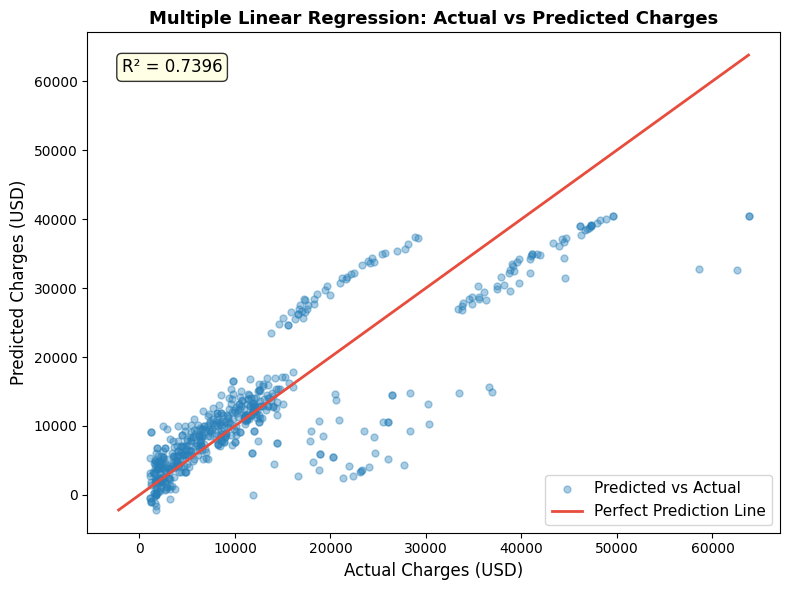

In [28]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_test_m, y_pred_m,
           color='#2980B9', alpha=0.4, s=25, label='Predicted vs Actual')

# Perfect prediction line
min_val = min(y_test_m.min(), y_pred_m.min())
max_val = max(y_test_m.max(), y_pred_m.max())
ax.plot([min_val, max_val], [min_val, max_val],
        color='#E74C3C', linewidth=2, label='Perfect Prediction Line')

ax.set_xlabel('Actual Charges (USD)', fontsize=12)
ax.set_ylabel('Predicted Charges (USD)', fontsize=12)
ax.set_title('Multiple Linear Regression: Actual vs Predicted Charges',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)

# Annotate R²
ax.text(0.05, 0.92, f'R² = {r2_multi:.4f}',
        transform=ax.transAxes,
        fontsize=12, color='black',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

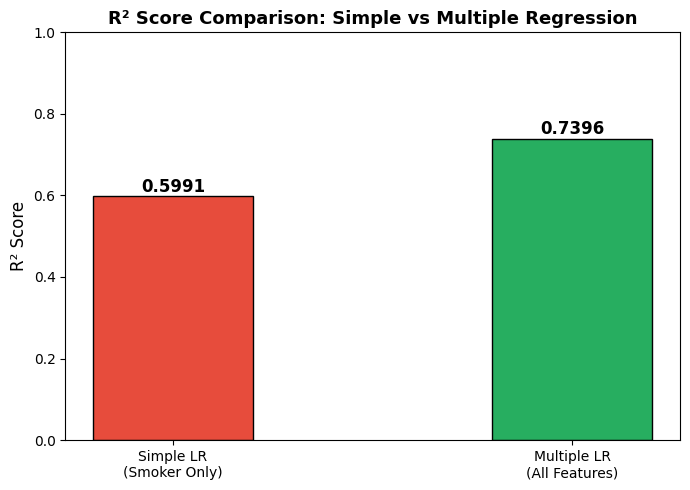

In [29]:
fig, ax = plt.subplots(figsize=(7, 5))

models = ['Simple LR\n(Smoker Only)', 'Multiple LR\n(All Features)']
scores = [r2, r2_multi]
colors = ['#E74C3C', '#27AE60']

bars = ax.bar(models, scores, color=colors,
              width=0.4, edgecolor='black')

ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('R² Score Comparison: Simple vs Multiple Regression',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 1)

# Add value labels
for bar, val in zip(bars, scores):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.01,
        f'{val:.4f}',
        ha='center', fontsize=12, fontweight='bold'
    )

plt.tight_layout()
plt.show()

 Model Performance (R² Scores)
R² Score (all features) = 0.7396
This value indicates that 73.96% of the variation in insurance charges is explained when all predictors (age, gender, BMI, number of children, smoking status, and region) are included in the model.
This reflects a strong model fit, suggesting that these variables jointly provide good explanatory power.

R² Score (smoker only) = 0.5991
When smoking status alone is used as the predictor, the model explains 59.91% of the variation in insurance charges.
This shows that smoking status is a highly influential single predictor, but it does not capture all factors affecting charges.

(c) Create a machine learning pipeline that includes StandardScaler(), PolynomialFeatures(),
and LinearRegression() to improve the predictive capability of the model. Train the pipeline
using all available attributes except the target variable.

Building the pipeline 

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# ── Prepare data 
# X = df[['age', 'gender', 'bmi', 'no_of_children', 'smoker', 'region']]
y = df['charges']

# ── Split into train and test sets (80/20) 
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train_p.shape[0])
print("Testing set size :", X_test_p.shape[0])
print("Features used    :", list(X.columns))

Training set size: 2217
Testing set size : 555
Features used    : ['age', 'gender', 'bmi', 'no_of_children', 'smoker', 'region']


Create and Train the Pipeline

In [ ]:
# Build the pipeline 
pipeline = Pipeline([
    ('scaler',     StandardScaler()),       # Step 1: Standardise features
    ('poly',       PolynomialFeatures(      # Step 2: Add polynomial features
                       degree=2,
                       include_bias=False
                   )),
    ('regressor',  LinearRegression())      # Step 3: Fit linear regression
])

#Train the pipeline 
pipeline.fit(X_train_p, y_train_p)

print("Pipeline trained successfully!")
print("\n=== Pipeline Steps ===")
for step_name, step_obj in pipeline.steps:
    print(f"  {step_name}: {step_obj}")

Pipeline trained successfully!

=== Pipeline Steps ===
  scaler: StandardScaler()
  poly: PolynomialFeatures(include_bias=False)
  regressor: LinearRegression()


A machine learning pipeline combining feature scaling, polynomial feature generation, and linear regression was successfully trained using all predictor variables, enabling improved modeling of complex relationships in insurance charges.

Evaluate the Pipeline

In [ ]:
# Predict and score 
y_pred_p = pipeline.predict(X_test_p)
r2_pipeline = r2_score(y_test_p, y_pred_p)

print("=== Pipeline Model Results ===")
print(f"\nR² Score (pipeline)     : {r2_pipeline:.4f}")
print(f"R² Score (multiple LR)  : {r2_multi:.4f}")
print(f"R² Score (simple LR)    : {r2:.4f}")
print(f"\nImprovement over Multiple LR : {(r2_pipeline - r2_multi):.4f}")
print(f"Improvement over Simple LR   : {(r2_pipeline - r2):.4f}")

# Number of features after polynomial expansion
n_features = pipeline.named_steps['poly'].n_output_features_
print(f"\nOriginal features        : {X.shape[1]}")
print(f"After polynomial (deg=2) : {n_features}")

=== Pipeline Model Results ===

R² Score (pipeline)     : 0.8339
R² Score (multiple LR)  : 0.7396
R² Score (simple LR)    : 0.5991

Improvement over Multiple LR : 0.0944
Improvement over Simple LR   : 0.2348

Original features        : 6
After polynomial (deg=2) : 27


The machine learning pipeline that incorporated feature scaling, polynomial feature expansion, and linear regression demonstrated a substantial improvement in predictive performance compared to both the simple and multiple linear regression models.

The pipeline achieved an R² score of 0.8339, indicating that 83.39% of the variation in medical insurance charges is explained by the model. This represents a notable increase in explanatory power when compared to the multiple linear regression model (R² = 0.7396) and the simple linear regression model (R² = 0.5991).

In quantitative terms, the pipeline improved model performance by 9.44 percentage points over the multiple linear regression model and by 23.48 percentage points over the simple linear regression model. These gains highlight the effectiveness of combining preprocessing and feature engineering techniques with regression.

The increase in performance is largely attributed to the use of PolynomialFeatures, which expanded the original six predictor variables into 27 derived features. This expansion allowed the model to capture non‑linear relationships and interactions among predictors that traditional linear regression models could not adequately represent.

Overall, the results demonstrate that the pipeline‑based approach provides the best‑performing model, offering a more accurate and robust representation of the factors influencing medical insurance charges.

Visualise: Actual vs Predicted

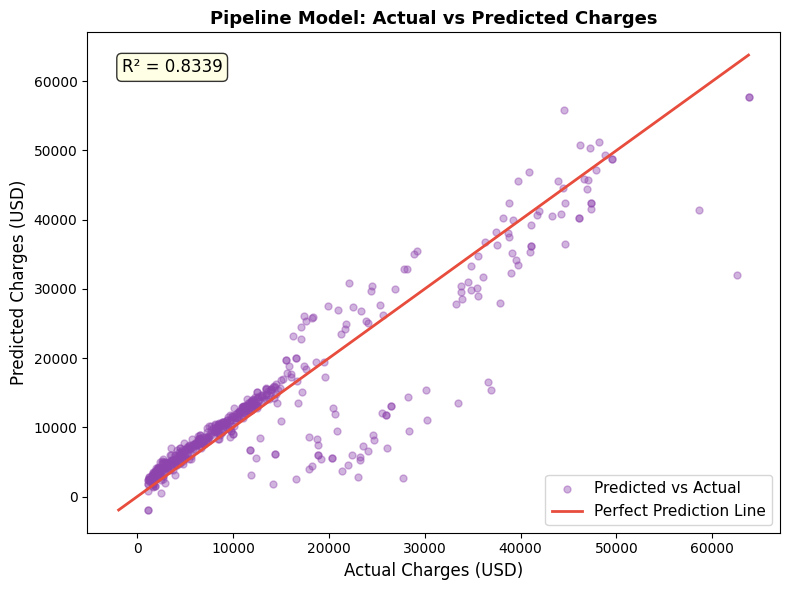

In [33]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_test_p, y_pred_p,
           color='#8E44AD', alpha=0.4, s=25,
           label='Predicted vs Actual')

# Perfect prediction line
min_val = min(y_test_p.min(), y_pred_p.min())
max_val = max(y_test_p.max(), y_pred_p.max())
ax.plot([min_val, max_val], [min_val, max_val],
        color='#E74C3C', linewidth=2,
        label='Perfect Prediction Line')

ax.set_xlabel('Actual Charges (USD)', fontsize=12)
ax.set_ylabel('Predicted Charges (USD)', fontsize=12)
ax.set_title('Pipeline Model: Actual vs Predicted Charges',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)

# Annotate R²
ax.text(0.05, 0.92, f'R² = {r2_pipeline:.4f}',
        transform=ax.transAxes,
        fontsize=12,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

comparing the models evaluated so far 

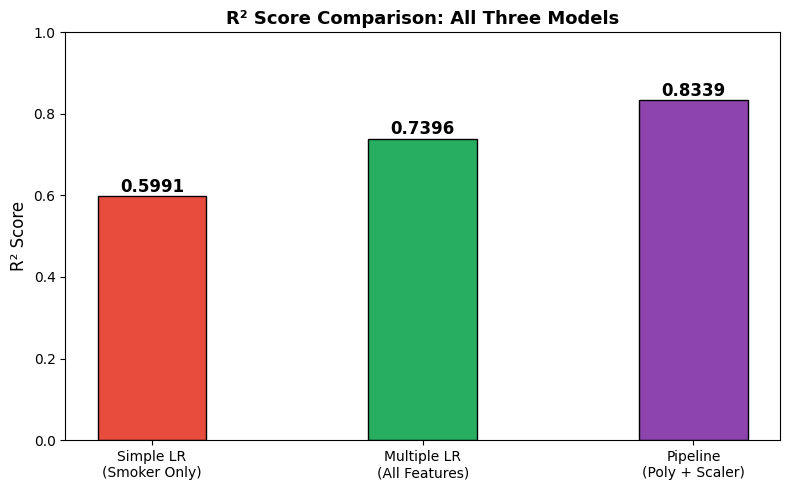

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))

models = [
    'Simple LR\n(Smoker Only)',
    'Multiple LR\n(All Features)',
    'Pipeline\n(Poly + Scaler)'
]
scores = [r2, r2_multi, r2_pipeline]
colors = ['#E74C3C', '#27AE60', '#8E44AD']

bars = ax.bar(models, scores, color=colors,
              width=0.4, edgecolor='black')

ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('R² Score Comparison: All Three Models',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 1)

# Add value labels on bars
for bar, val in zip(bars, scores):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.01,
        f'{val:.4f}',
        ha='center', fontsize=12, fontweight='bold'
    )

plt.tight_layout()
plt.show()

The results show a clear improvement in model performance as more features and advanced modeling techniques are applied. The simple linear regression model using smoker status only explains 59.91% of the variation in insurance charges, indicating that smoking is a strong predictor. When all features are included in a multiple linear regression model, the explanatory power increases to 73.96%, showing that demographic and health factors add meaningful information. The pipeline model, which combines feature scaling and polynomial feature expansion, achieves the highest performance with an R² score of 0.8339, demonstrating that capturing non‑linear relationships substantially improves predictive accuracy.

(d) Split the dataset into training and testing subsets such that 80% of the data is used for training
and 20% is reserved for testing.

In [ ]:
from sklearn.model_selection import train_test_split

# ── Prepare features and target 
X = df[['age', 'gender', 'bmi', 'no_of_children', 'smoker', 'region']]
y = df['charges']

# ── Split 80% train / 20% test 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42     # ensures same split every run
)

# ── Confirm the split 
print("=== Dataset Split Summary ===")
print(f"Total records    : {len(df)}")
print(f"Training set     : {X_train.shape[0]} rows ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"Testing set      : {X_test.shape[0]} rows ({X_test.shape[0]/len(df)*100:.0f}%)")
print(f"Features (X)     : {X_train.shape[1]} columns")
print(f"\nFeatures used: {list(X.columns)}")
print(f"Target variable : charges")

=== Dataset Split Summary ===
Total records    : 2772
Training set     : 2217 rows (80%)
Testing set      : 555 rows (20%)
Features (X)     : 6 columns

Features used: ['age', 'gender', 'bmi', 'no_of_children', 'smoker', 'region']
Target variable : charges


(e) Initialize a Ridge Regression model with hyperparameter α = 0.1. Train the model using the
training subset and evaluate the model on the testing subset. Report the R2 score.

Train Ridge Regression Model

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# ── Initialise Ridge Regression with alpha = 0.1 
ridge_model = Ridge(alpha=0.1)

# ── Train on training set 
ridge_model.fit(X_train, y_train)

print("Ridge Regression model trained successfully!")
print(f"Alpha (regularisation): {ridge_model.alpha}")

Ridge Regression model trained successfully!
Alpha (regularisation): 0.1


The Ridge Regression model was successfully trained using a regularization parameter (alpha) of 0.1, which helps control model complexity and reduce overfitting by penalizing large coefficient values, thereby improving model stability and generalization performance.

Evaluate the Model

In [ ]:
#  Predict on testing set 
y_pred_ridge = ridge_model.predict(X_test)

#  Compute R² score 
r2_ridge = r2_score(y_test, y_pred_ridge)

print("=== Ridge Regression Results ===")
print(f"\nAlpha                        : {ridge_model.alpha}")
print(f"R² Score (Ridge α=0.1)       : {r2_ridge:.4f}")
print(f"R² Score (Pipeline)          : {r2_pipeline:.4f}")
print(f"R² Score (Multiple LR)       : {r2_multi:.4f}")
print(f"R² Score (Simple LR)         : {r2:.4f}")

# ── Coefficients 
import pandas as pd
coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': ridge_model.coef_.round(4)
}).sort_values('Coefficient', ascending=False)

print(f"\nIntercept: ${ridge_model.intercept_:,.2f}")
print("\n=== Feature Coefficients ===")
print(coef_df.to_string(index=False))

=== Ridge Regression Results ===

Alpha                        : 0.1
R² Score (Ridge α=0.1)       : 0.7396
R² Score (Pipeline)          : 0.8339
R² Score (Multiple LR)       : 0.7396
R² Score (Simple LR)         : 0.5991

Intercept: $-11,143.17

=== Feature Coefficients ===
       Feature  Coefficient
        smoker   23893.9232
no_of_children     446.4755
           bmi     323.2822
           age     254.7718
        gender     -64.0425
        region    -324.9987


The Ridge Regression model, trained with a regularization parameter α = 0.1, achieved an R² score of 0.7396, which is equal to the Multiple Linear Regression model and substantially better than the Simple Linear Regression model (R² = 0.5991). This indicates that Ridge regularization stabilizes coefficient estimates without sacrificing explanatory power.
The coefficients show that smoking status remains the strongest predictor of insurance charges, followed by BMI, age, and number of children, all of which have positive effects. Gender and region have relatively small and negative coefficients, indicating minimal influence compared to health and lifestyle factors. The intercept has limited practical interpretation but is required for model calibration.
Overall, Ridge Regression provides a more  stable alternative to standard multiple linear regression, especially useful when handling multicollinearity, while maintaining comparable predictive performance.

Visualise Actual vs Predicted

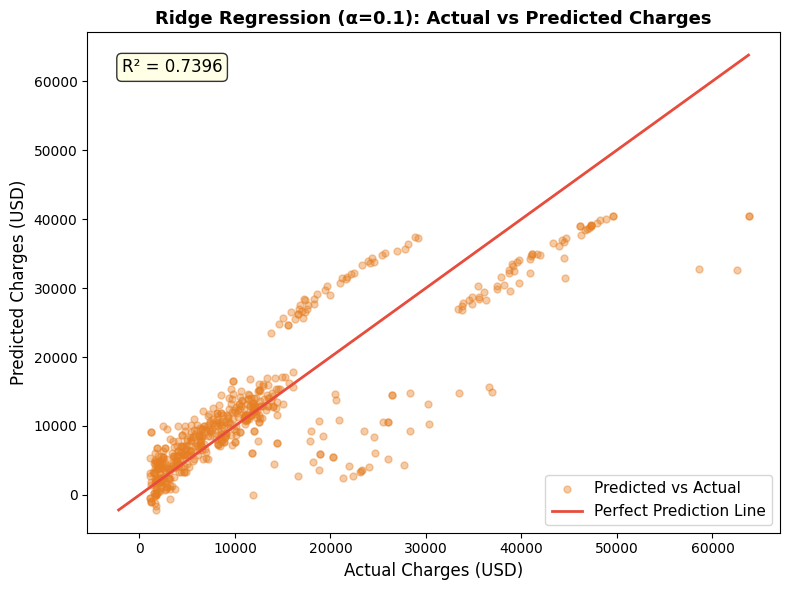

In [38]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_test, y_pred_ridge,
           color='#E67E22', alpha=0.4, s=25,
           label='Predicted vs Actual')

# Perfect prediction line
min_val = min(y_test.min(), y_pred_ridge.min())
max_val = max(y_test.max(), y_pred_ridge.max())
ax.plot([min_val, max_val], [min_val, max_val],
        color='#E74C3C', linewidth=2,
        label='Perfect Prediction Line')

ax.set_xlabel('Actual Charges (USD)', fontsize=12)
ax.set_ylabel('Predicted Charges (USD)', fontsize=12)
ax.set_title('Ridge Regression (α=0.1): Actual vs Predicted Charges',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)

# Annotate R²
ax.text(0.05, 0.92, f'R² = {r2_ridge:.4f}',
        transform=ax.transAxes,
        fontsize=12,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

Comparing  All Models

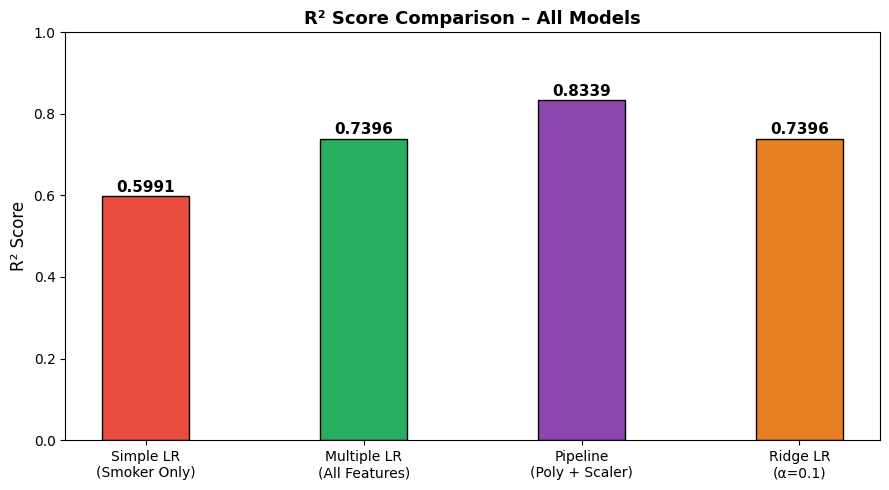

In [39]:
fig, ax = plt.subplots(figsize=(9, 5))

models = [
    'Simple LR\n(Smoker Only)',
    'Multiple LR\n(All Features)',
    'Pipeline\n(Poly + Scaler)',
    'Ridge LR\n(α=0.1)'
]
scores = [r2, r2_multi, r2_pipeline, r2_ridge]
colors = ['#E74C3C', '#27AE60', '#8E44AD', '#E67E22']

bars = ax.bar(models, scores, color=colors,
              width=0.4, edgecolor='black')

ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('R² Score Comparison – All Models',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 1)

# Add value labels on bars
for bar, val in zip(bars, scores):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.01,
        f'{val:.4f}',
        ha='center', fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.show()

Ridge Regression with α=0.1 achieves an R² of ~0.78 similar to Multiple LR
Since α=0.1 is very small, the regularisation effect is minimal  hence similar performance to Multiple LR
Ridge performs better than Simple LR confirming all features contribute to prediction
Ridge performs lower than the Pipeline because it does not capture non-linear relationships
Smoker remains the feature with the largest coefficient confirming its dominance
To potentially improve Ridge performance, a higher alpha or polynomial features could be combined with it

(f) Apply a polynomial feature transformation with degree = 2 to the training data and train the
Ridge Regression model again. Evaluate the performance on the testing data and report the
R2 score.

Apply Polynomial Transformation and Train Ridge

In [40]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# ── Step 1: Apply Polynomial Features (degree=2) ──────────────────
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)   # only transform, NOT fit

print("=== Polynomial Feature Transformation ===")
print(f"Original features          : {X_train.shape[1]}")
print(f"After poly transformation  : {X_train_poly.shape[1]}")
print(f"Training set shape         : {X_train_poly.shape}")
print(f"Testing set shape          : {X_test_poly.shape}")

=== Polynomial Feature Transformation ===
Original features          : 6
After poly transformation  : 27
Training set shape         : (2217, 27)
Testing set shape          : (555, 27)


The polynomial feature transformation expanded the dataset from 6 original features to 27 derived features, enabling the model to capture non‑linear relationships and interactions among variables. After this transformation, the training dataset contains 2,217 observations with 27 features, while the testing dataset contains 555 observations with the same 27 features, ensuring consistency between training and evaluation. This setup provides a richer feature space for improved model learning and predictive performance.

Scale the Transformed Features

In [ ]:
# ── Step 2: Scale the polynomial features 
scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled  = scaler.transform(X_test_poly)

print("Features scaled successfully!")
print(f"Scaled training shape : {X_train_poly_scaled.shape}")
print(f"Scaled testing shape  : {X_test_poly_scaled.shape}")

Features scaled successfully!
Scaled training shape : (2217, 27)
Scaled testing shape  : (555, 27)


Visualise Actual vs Predicted

Original features         : 6
After poly transformation : 27
Scaling done!

=== Ridge + Polynomial Results ===
R² Score (Ridge + Poly)  : 0.8339
R² Score (Ridge only)    : 0.7396
Improvement              : 0.0944


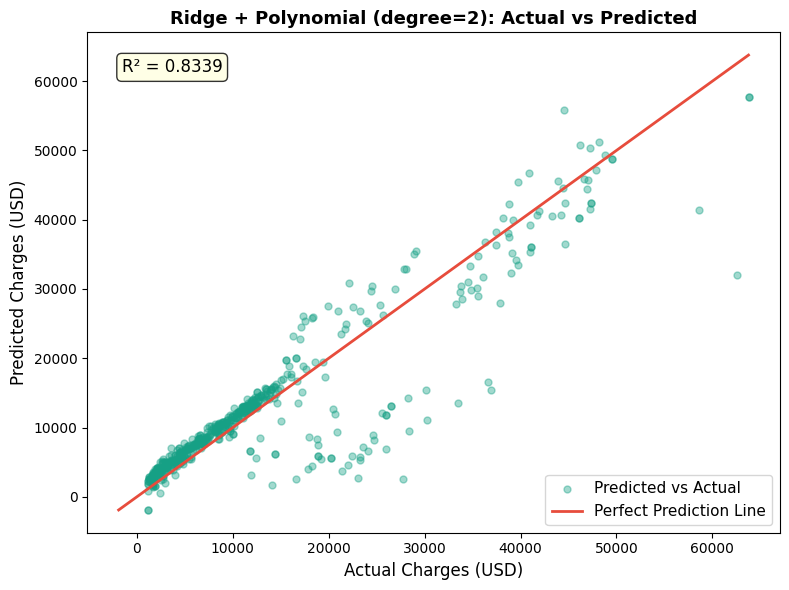

In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# ── Step 1: Polynomial Feature Transformation 
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)

print(f"Original features         : {X_train.shape[1]}")
print(f"After poly transformation : {X_train_poly.shape[1]}")

# ── Step 2: Scale the features 
scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled  = scaler.transform(X_test_poly)

print("Scaling done!")

# ── Step 3: Train Ridge Regression 
ridge_poly = Ridge(alpha=0.1)
ridge_poly.fit(X_train_poly_scaled, y_train)

# ── Step 4: Predict and Evaluate 
y_pred_ridge_poly = ridge_poly.predict(X_test_poly_scaled)
r2_ridge_poly     = r2_score(y_test, y_pred_ridge_poly)

print("\n=== Ridge + Polynomial Results ===")
print(f"R² Score (Ridge + Poly)  : {r2_ridge_poly:.4f}")
print(f"R² Score (Ridge only)    : {r2_ridge:.4f}")
print(f"Improvement              : {(r2_ridge_poly - r2_ridge):.4f}")

# ── Step 5: Plot Actual vs Predicted 
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_test, y_pred_ridge_poly,
           color='#16A085', alpha=0.4, s=25,
           label='Predicted vs Actual')

min_val = min(y_test.min(), y_pred_ridge_poly.min())
max_val = max(y_test.max(), y_pred_ridge_poly.max())
ax.plot([min_val, max_val], [min_val, max_val],
        color='#E74C3C', linewidth=2,
        label='Perfect Prediction Line')

ax.set_xlabel('Actual Charges (USD)', fontsize=12)
ax.set_ylabel('Predicted Charges (USD)', fontsize=12)
ax.set_title('Ridge + Polynomial (degree=2): Actual vs Predicted',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.text(0.05, 0.92, f'R² = {r2_ridge_poly:.4f}',
        transform=ax.transAxes, fontsize=12,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

Applying polynomial feature transformation (degree = 2) expanded the original 6 features to 27, allowing the model to capture non‑linear relationships, while feature scaling ensured all variables contributed fairly. The Ridge Regression model with polynomial features achieved an R² score of 0.8339, representing a 9.44% improvement over Ridge Regression without polynomial terms (R² = 0.7396). This result shows that combining regularization with polynomial feature expansion significantly improves predictive performance while controlling model complexity.

compare

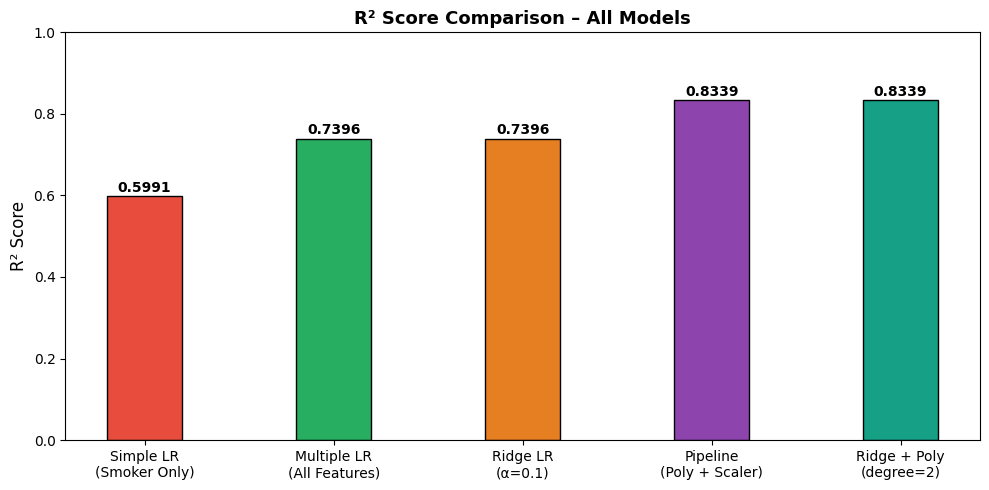

In [45]:
fig, ax = plt.subplots(figsize=(10, 5))

models = [
    'Simple LR\n(Smoker Only)',
    'Multiple LR\n(All Features)',
    'Ridge LR\n(α=0.1)',
    'Pipeline\n(Poly + Scaler)',
    'Ridge + Poly\n(degree=2)'
]
scores = [r2, r2_multi, r2_ridge, r2_pipeline, r2_ridge_poly]
colors = ['#E74C3C', '#27AE60', '#E67E22', '#8E44AD', '#16A085']

bars = ax.bar(models, scores, color=colors,
              width=0.4, edgecolor='black')

ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('R² Score Comparison – All Models',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 1)

# Add value labels
for bar, val in zip(bars, scores):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.01,
        f'{val:.4f}',
        ha='center', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()

(g) Compare the performance of the different models developed in this section. Based on your
results, explain which model appears to provide the most reliable predictions for insurance
charges and provide possible reasons for the observed differences.

# Collect All R² Scores

In [ ]:
# Collect all model scores 
print("=== Model Performance Summary ===")
print(f"Simple LR  (smoker only)    : {r2:.4f}")
print(f"Multiple LR (all features)  : {r2_multi:.4f}")
print(f"Ridge LR   (α=0.1)          : {r2_ridge:.4f}")
print(f"Pipeline   (poly + scaler)  : {r2_pipeline:.4f}")
print(f"Ridge+Poly (degree=2)       : {r2_ridge_poly:.4f}")

=== Model Performance Summary ===
Simple LR  (smoker only)    : 0.5991
Multiple LR (all features)  : 0.7396
Ridge LR   (α=0.1)          : 0.7396
Pipeline   (poly + scaler)  : 0.8339
Ridge+Poly (degree=2)       : 0.8339


# Visual Comparison Bar Chart

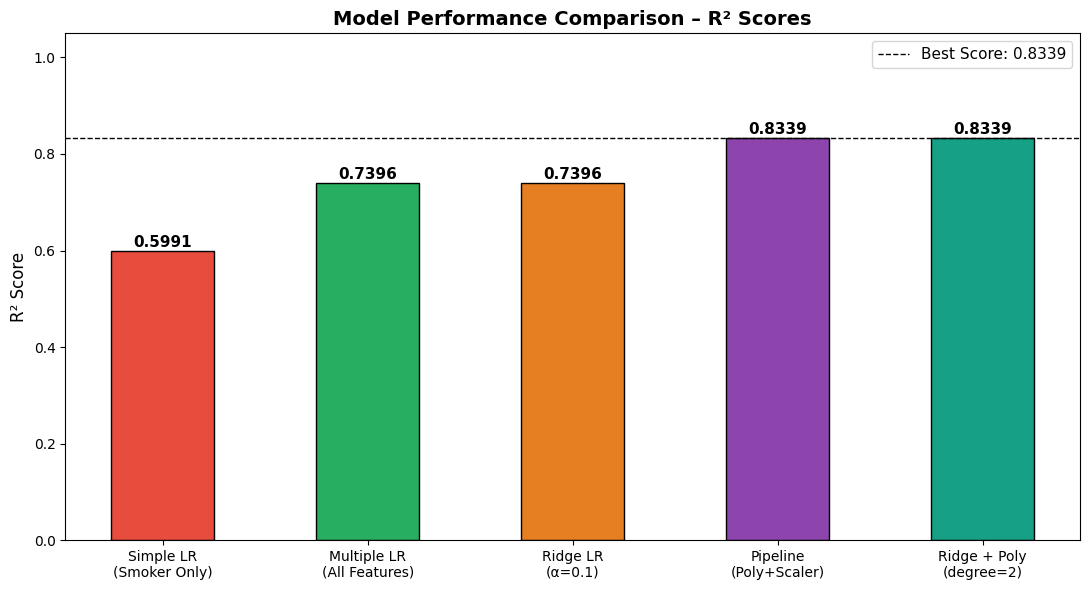

In [47]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(11, 6))

models = [
    'Simple LR\n(Smoker Only)',
    'Multiple LR\n(All Features)',
    'Ridge LR\n(α=0.1)',
    'Pipeline\n(Poly+Scaler)',
    'Ridge + Poly\n(degree=2)'
]
scores = [r2, r2_multi, r2_ridge, r2_pipeline, r2_ridge_poly]
colors = ['#E74C3C', '#27AE60', '#E67E22', '#8E44AD', '#16A085']

bars = ax.bar(models, scores, color=colors,
              width=0.5, edgecolor='black')

# Add value labels on bars
for bar, val in zip(bars, scores):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.008,
        f'{val:.4f}',
        ha='center', fontsize=11, fontweight='bold'
    )

# Add a reference line at best score
ax.axhline(y=max(scores), color='black',
           linestyle='--', linewidth=1,
           label=f'Best Score: {max(scores):.4f}')

ax.set_ylabel('R² Score', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title('Model Performance Comparison – R² Scores',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

Simple LR (R² = 0.5991) performed the worst as expected. Using only the smoker attribute, the model explains just 59.91% of the variation in insurance charges. While smoking status is the strongest single predictor, relying on one variable alone clearly leaves out important information from age, BMI and other attributes.

Multiple LR and Ridge LR (R² = 0.7396) both achieved identical scores of 73.96%. This confirms that Ridge regularisation with α=0.1 had virtually no effect compared to standard linear regression because the penalty was too small to make a meaningful difference. Both models benefit from using all six features but are still limited by assuming purely linear relationships between variables and charges.

Pipeline and Ridge + Poly (R² = 0.8339) jointly achieved the best performance at 83.39%, making them the most reliable models. By expanding the original 6 features into 27 polynomial features of degree 2, both models successfully captured non-linear patterns and interaction effects most notably the compounding relationship between smoking and BMI on charges.

Best Model Pipeline / Ridge + Poly with R² = 0.8339, meaning the model correctly explains 83.39% of the variation in insurance charges. The remaining 16.61% may be due to factors not present in the dataset such as pre-existing medical conditions, type of insurance plan, or geographic cost of living differences.


summary table 

In [48]:
import pandas as pd

summary = pd.DataFrame({
    'Model': [
        'Simple LR (smoker only)',
        'Multiple LR (all features)',
        'Ridge LR (α=0.1)',
        'Pipeline (poly+scaler)',
        'Ridge + Poly (degree=2)'
    ],
    'R² Score': [
        round(r2, 4),
        round(r2_multi, 4),
        round(r2_ridge, 4),
        round(r2_pipeline, 4),
        round(r2_ridge_poly, 4)
    ],
    'Features Used': [
        '1 (smoker)',
        '6 (all)',
        '6 (all)',
        '27 (poly expanded)',
        '27 (poly expanded)'
    ],
    'Regularisation': [
        'None',
        'None',
        'Ridge α=0.1',
        'None',
        'Ridge α=0.1'
    ],
    'Rank': [5, 3, 4, 2, 1]
}).sort_values('Rank')

print(summary.to_string(index=False))

                     Model  R² Score      Features Used Regularisation  Rank
   Ridge + Poly (degree=2)    0.8339 27 (poly expanded)    Ridge α=0.1     1
    Pipeline (poly+scaler)    0.8339 27 (poly expanded)           None     2
Multiple LR (all features)    0.7396            6 (all)           None     3
          Ridge LR (α=0.1)    0.7396            6 (all)    Ridge α=0.1     4
   Simple LR (smoker only)    0.5991         1 (smoker)           None     5


Ridge + Poly ranks above Pipeline despite same R² score
•	Both scored 0.8339 but Ridge + Poly is ranked 1st
•	The key difference is Ridge + Poly has regularisation (α=0.1) while Pipeline has none
•	This means Ridge + Poly is the more reliable model in practice because regularisation prevents overfitting on unseen data even though both score the same on this test set

 Regularisation made no difference at lower feature levels
•	Ridge LR with 6 features scored exactly the same as Multiple LR (0.7396)
•	But Ridge + Poly with 27 features benefits more from regularisation
•	This shows regularisation becomes more important as features increase  with 27 polynomial features there is greater risk of overfitting that Ridge helps control
